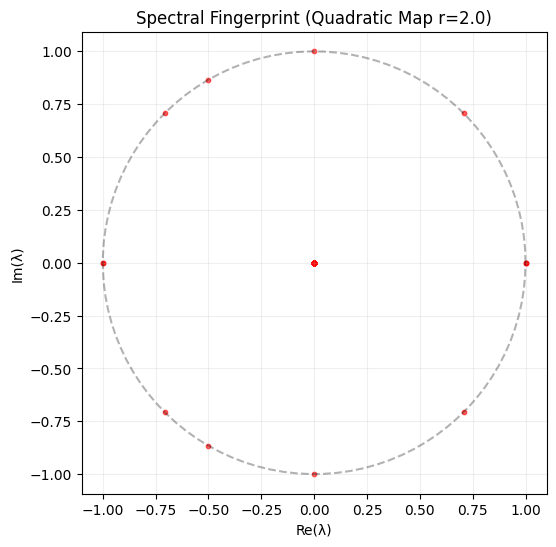

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_map_spectrum(r=2.0, N=500):
    # 1. 离散化区间 [-1, 1]
    edges = np.linspace(-1, 1, N + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    
    # 2. 构造转移矩阵 P (Perron-Frobenius 算子的离散近似)
    P = np.zeros((N, N))
    
    # 对每个格子中心点进行映射，看它落到哪个新格子
    for j in range(N):
        x_next = 1 - r * (centers[j]**2)
        # 找到落在哪个 bin (利用 searchsorted 快速定位)
        if -1 <= x_next <= 1:
            i = np.searchsorted(edges, x_next) - 1
            if 0 <= i < N:
                P[i, j] = 1.0  # 确定性映射
    
    # 3. 计算特征值
    eigenvalues = np.linalg.eigvals(P)
    
    # 4. 绘图
    plt.figure(figsize=(6, 6))
    # 画出单位圆
    theta = np.linspace(0, 2*np.pi, 100)
    plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
    
    # 画出特征值分布
    plt.scatter(eigenvalues.real, eigenvalues.imag, s=10, c='red', alpha=0.6)
    
    plt.title(f"Spectral Fingerprint (Quadratic Map r={r})")
    plt.xlabel("Re(λ)")
    plt.ylabel("Im(λ)")
    plt.grid(True, alpha=0.2)
    plt.axis('equal')
    plt.show()

# 运行混沌态
quadratic_map_spectrum(r=2.0, N=1000)